## INTRODUCTION
The rice leaf suffers from several bacterial, viral, or fungal diseases and these diseases reduce rice production significantly. To sustain rice demand for a vast population globally.The rice leaves related diseases often pose threats to the sustainable production of rice affecting many farmers around the world. Early diagnosis and appropriate remedy of the rice leaf infection is crucial in facilitating healthy growth of the rice plants to ensure adequate supply and food security to the rapidly increasing population.
### RICE LEAF DISEASE:
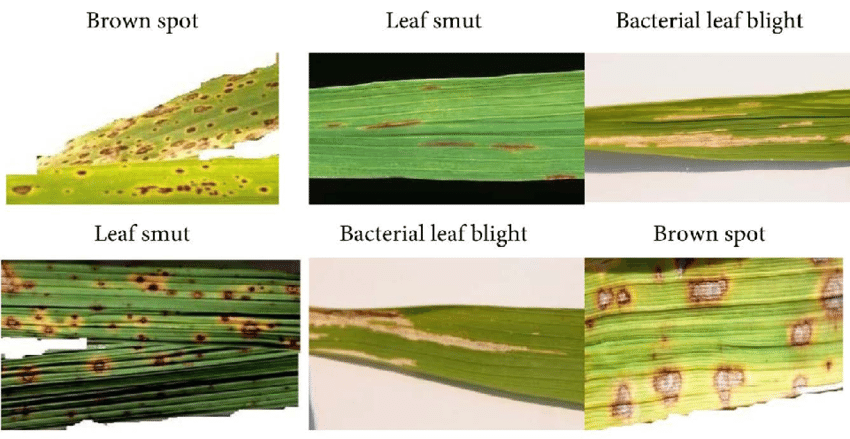

In [4]:
import os
print(os.listdir(r"C:\ML\RiceLeaf-Disease-Detector"))

['.git', '.ipynb_checkpoints', '.venv', 'Bacterial_Rice_leaf.ipynb', 'bacterical disease', 'gitattributes', 'Project report on rice leaf disease.docx', 'README.md']


In [6]:
import sys
print(sys.executable)

C:\ML\RiceLeaf-Disease-Detector\.venv\Scripts\python.exe


In [7]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [9]:
import cv2
print(cv2.__version__)

4.8.1


In [19]:
import os
print(os.listdir(r"C:\ML\RiceLeaf-Disease-Detector"))

['.git', '.ipynb_checkpoints', '.venv', 'Bacterial_Rice_leaf.ipynb', 'bacterical disease', 'gitattributes', 'Project report on rice leaf disease.docx', 'README.md']


In [20]:
import os
print(os.listdir(train_dir))

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [11]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
%matplotlib inline
import random
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
print("done")

done


In [22]:
# # Sorting the path of data into veriable

train_dir = r"C:\ML\RiceLeaf-Disease-Detector\bacterical disease"
validation_dir = r"C:\ML\RiceLeaf-Disease-Detector\bacterical disease"
test_dir = r"C:\ML\RiceLeaf-Disease-Detector\bacterical disease"

print("done")

done


### GENERATING TRAINING AND VALIDATION BATCHES OF IMAGES

In [31]:
# Generating batches of image data
train_datagen = ImageDataGenerator(
    rescale= (1./255),
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))




train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')


val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')


Found 120 images belonging to 3 classes.
Found 120 images belonging to 3 classes.


### PLOTTING TRAIN IMAGES WITH THEIR LABELS

In [32]:
# function for plotting train images with their labels
def plots(ims, figsize=(20,25), rows=4, interp = False, title = None):
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % 2 ==0 else len(ims) // rows+1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('off')
        sp.set_title(class_names[title[i].tolist().index(1)],fontsize=16)
        plt.imshow(ims[i])


# Make list of classes
class_names = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']
print("done")

done


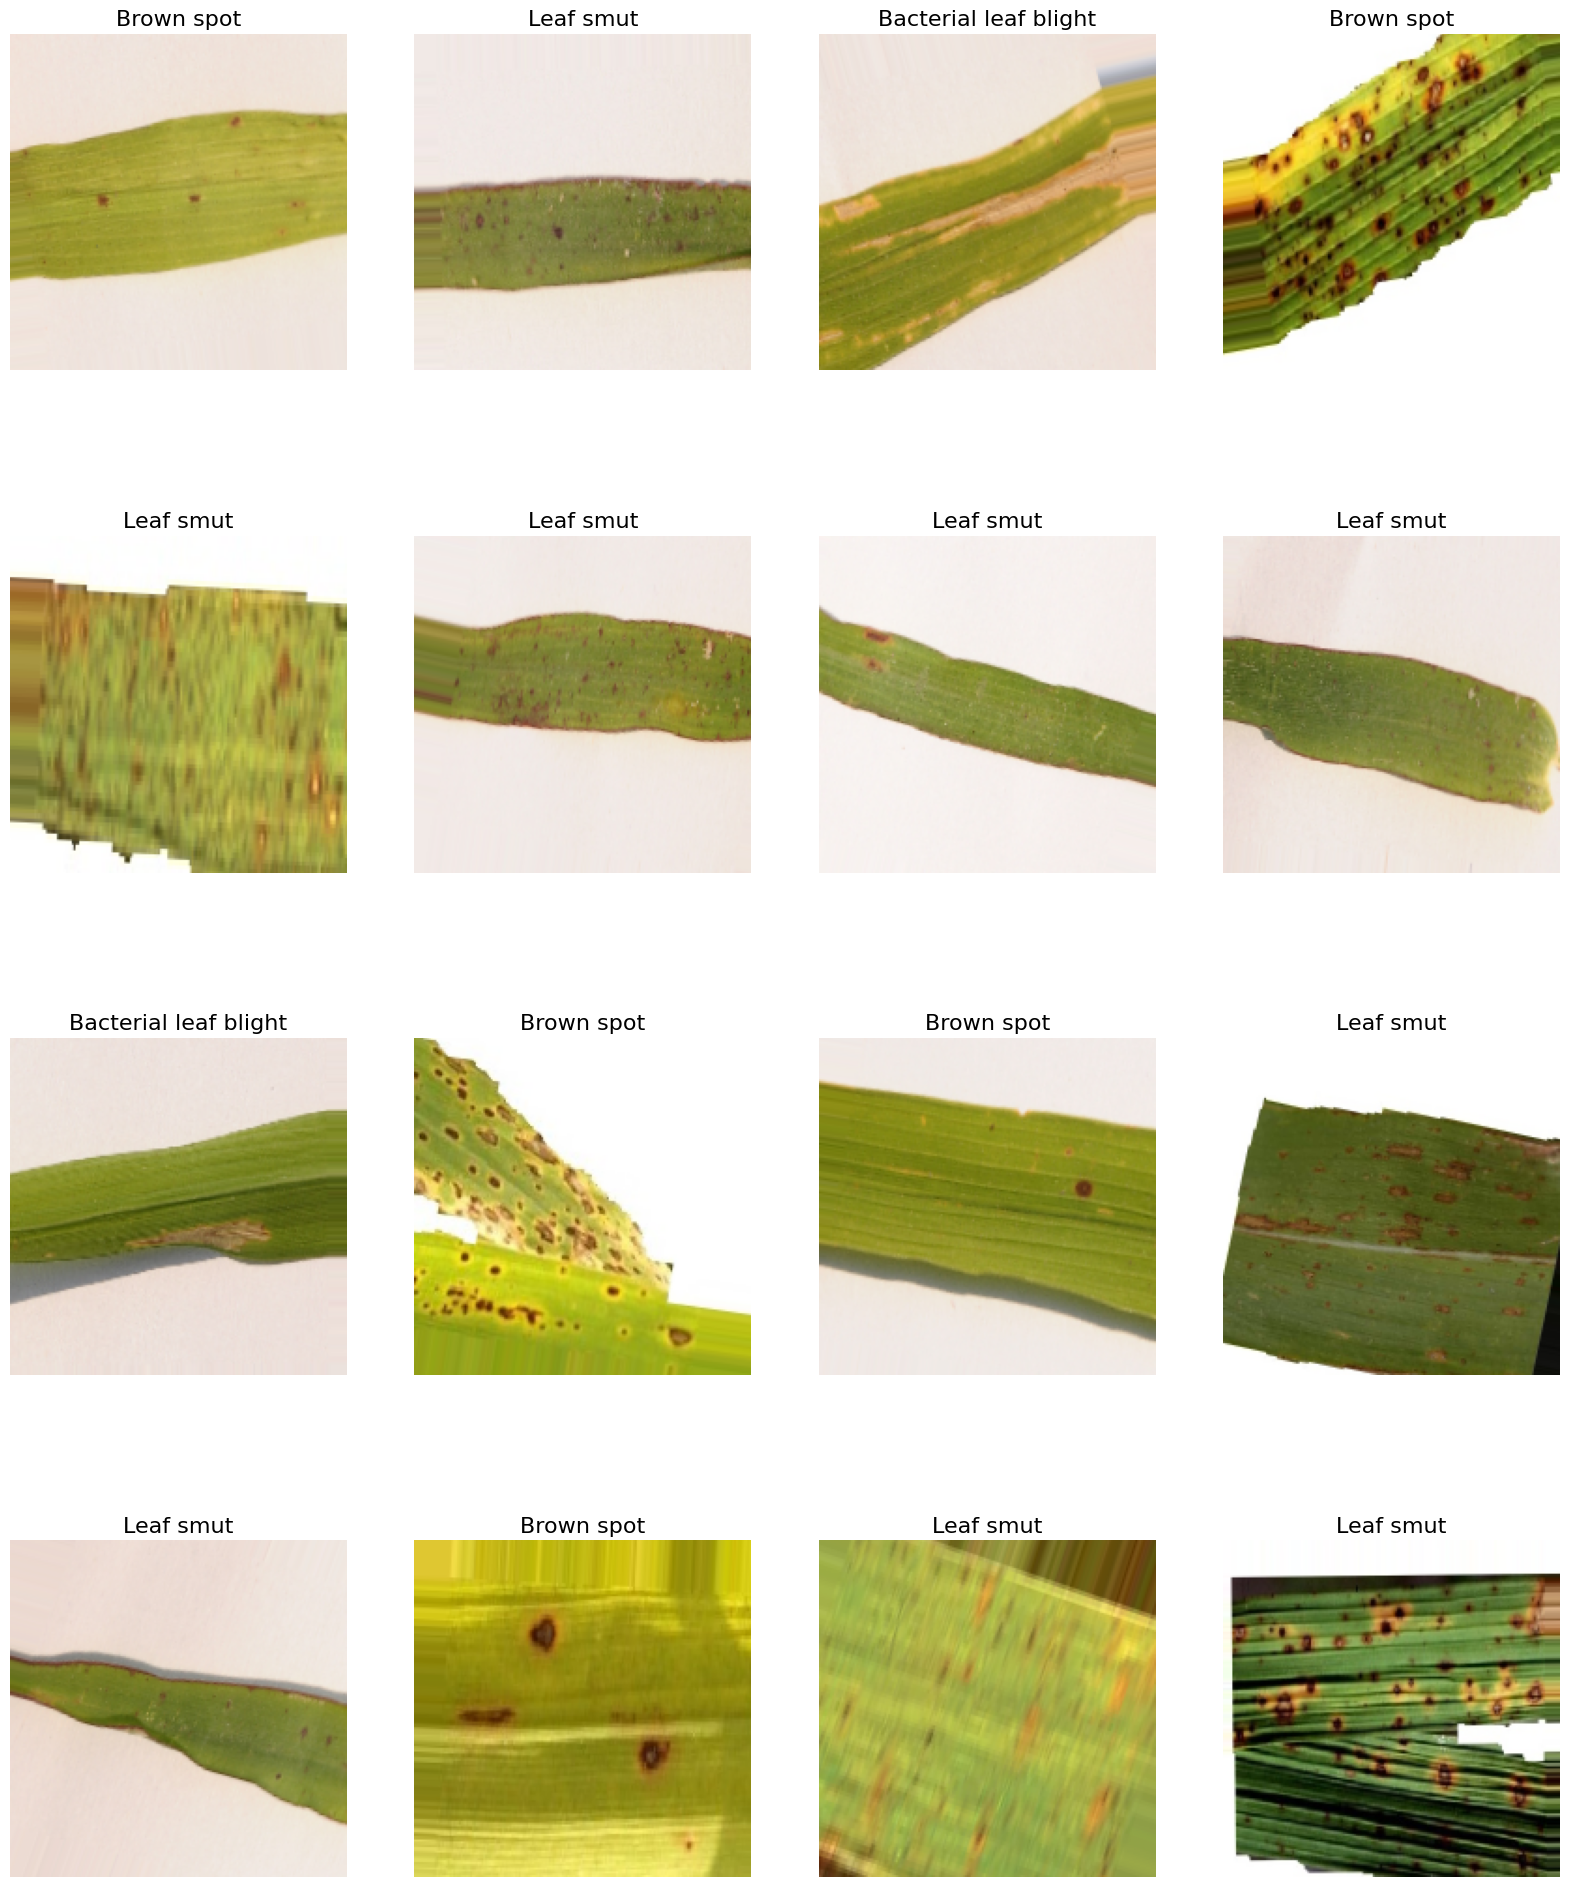

In [33]:
imgs, labels = next(train_generator)
plots(imgs, title = labels)

In [35]:
# the cnn model 

from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(180,180,3)))
model.add(layers.MaxPool2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPool2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPool2D((2,2)))

model.add(layers.Conv2D(256, (3,3), activation='relu'))
model.add(layers.MaxPool2D((2,2)))

model.add(layers.Dropout(0.3))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(3, activation='softmax'))

print("done")

done


In [36]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 41, 41, 128)       73856     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 20, 20, 128)      

In [38]:
# compiling

from tensorflow.keras import optimizers
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("done")

done


In [39]:
# Fitting the data
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=50,
    validation_data = val_generator,
    callbacks=[early_stop]
)

Epoch 1/50
8/8 [==============================] - 16s 2s/step - loss: 1.1792 - accuracy: 0.2917 - val_loss: 1.0952 - val_accuracy: 0.3417
Epoch 2/50
8/8 [==============================] - 12s 2s/step - loss: 1.0983 - accuracy: 0.2833 - val_loss: 1.0810 - val_accuracy: 0.4000
Epoch 3/50
8/8 [==============================] - 12s 2s/step - loss: 1.0727 - accuracy: 0.3250 - val_loss: 1.0252 - val_accuracy: 0.5250
Epoch 4/50
8/8 [==============================] - 12s 2s/step - loss: 1.0267 - accuracy: 0.5167 - val_loss: 1.2041 - val_accuracy: 0.3417
Epoch 5/50
8/8 [==============================] - 12s 2s/step - loss: 1.0898 - accuracy: 0.3500 - val_loss: 1.0075 - val_accuracy: 0.4917
Epoch 6/50
8/8 [==============================] - 12s 2s/step - loss: 0.9639 - accuracy: 0.4833 - val_loss: 0.8518 - val_accuracy: 0.7083
Epoch 7/50
8/8 [==============================] - 12s 2s/step - loss: 0.9757 - accuracy: 0.6167 - val_loss: 0.8485 - val_accuracy: 0.6333
Epoch 8/50
8/8 [==================

### AFTER TRAINING
* Validation accuracy 90.8%
* Training accuracy 88.33%

### MODEL SAVING

In [41]:
model.save("model.h5")
print("saved")

saved


### PLOTTING THE TRAINING ACCURACY AND VALIDATION ACCURACY AND TRAINING LOSS AND VALIDATION LOSS

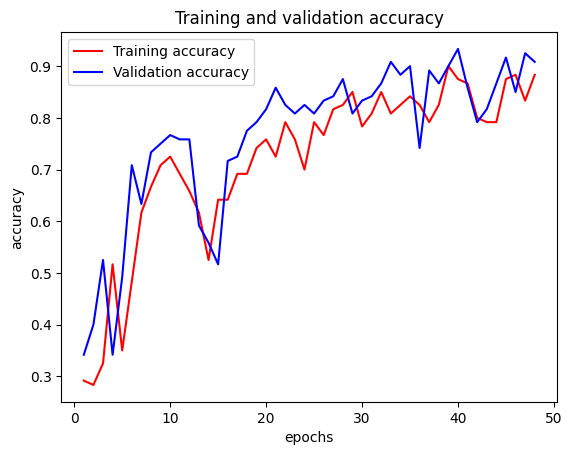

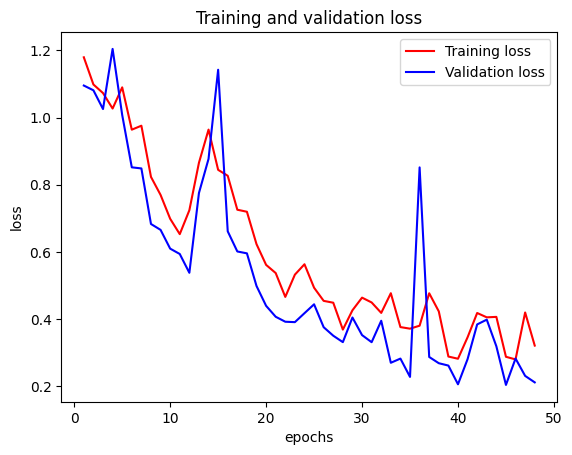

In [42]:
# Step:9 Plotting the training accuracy and validation accuracy
# Plotting the traning loss and validation loss
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

### CREATED MODEL SUMMARY

In [43]:
model = tf.keras.models.load_model("model.h5")
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 41, 41, 128)       73856     
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 20, 20, 128)      

### EVALUATION AND TESTING MODEL

In [44]:
test_datagen = ImageDataGenerator(rescale=(1./255))


test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

Found 120 images belonging to 3 classes.


In [45]:
model.evaluate(test_generator)

# loss: 0.2063
# accuracy: 0.9333

8/8 [==============================] - 4s 493ms/step - loss: 0.2063 - accuracy: 0.9333


[0.20631501078605652, 0.9333333373069763]

### VISUALISE THE PREDICTION OF MODEL

1/1 [==============================] - 0s 74ms/step


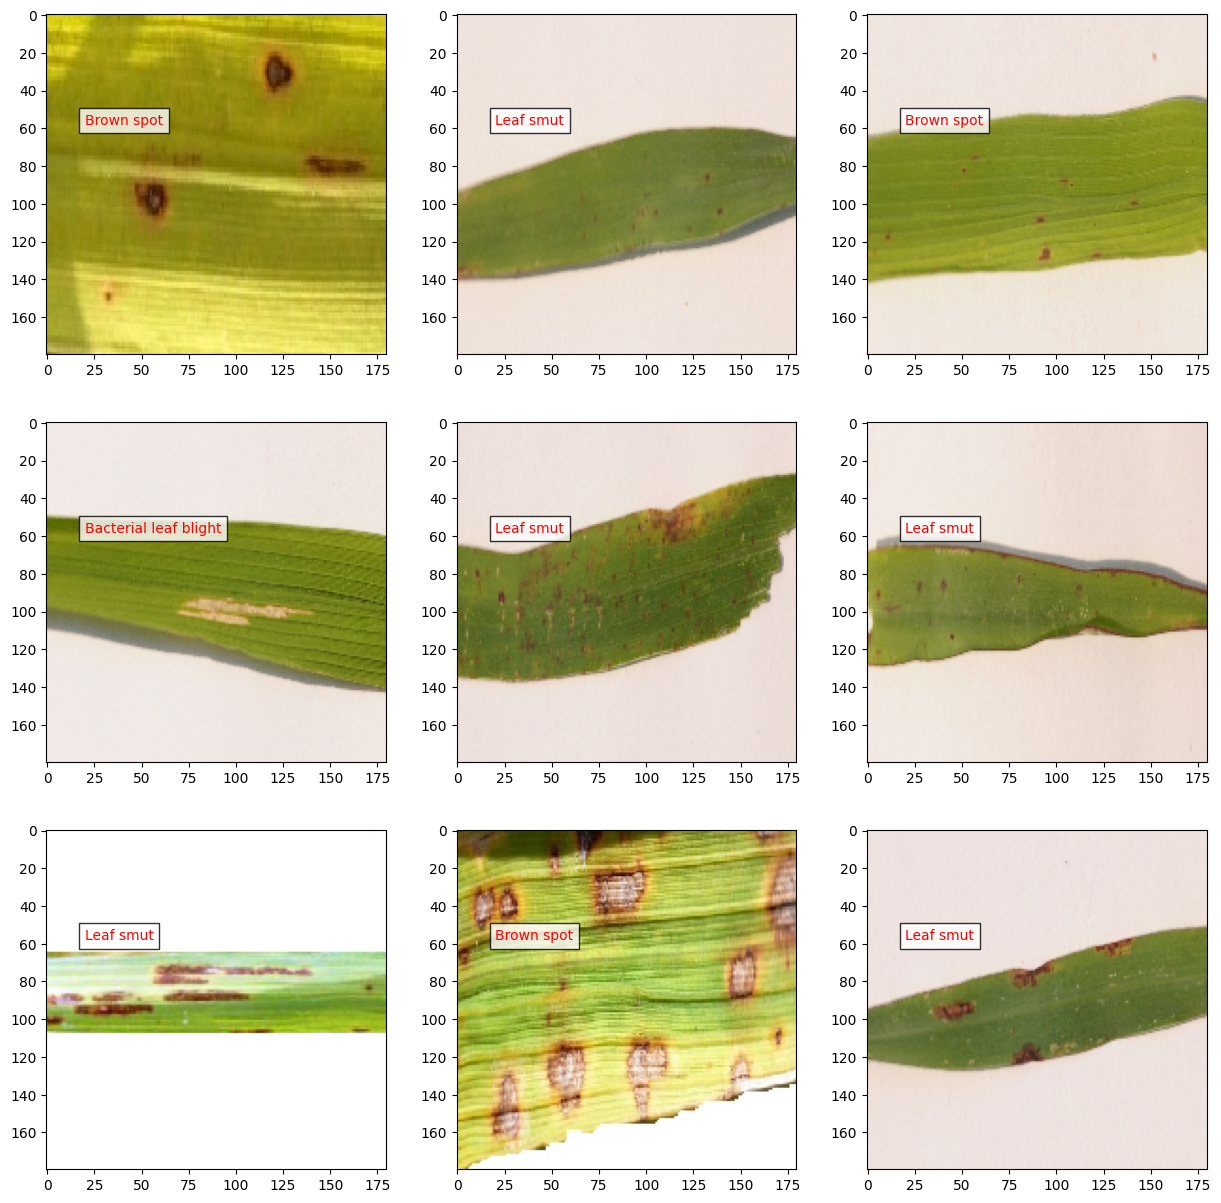

In [46]:
# Visualise the prediction of the model
imgs, labels = next(test_generator)
fig =plt.figure(figsize=(15,15))
columns = 3
rows = 3
for i in range(columns*rows):
    fig.add_subplot(rows, columns, i+1)
    img_t = np.expand_dims(imgs[i],axis=0)
    prediction = model.predict(img_t)
    idx = prediction[0].tolist().index(max(prediction[0]))
    plt.text(20,58, class_names[idx],color='red',fontsize=10,bbox=dict(facecolor='white',alpha=0.8))
    plt.imshow(imgs[i])


